Dataset loaded: 5726 messages.
Class Distribution:
spam
0    4358
1    1368
Name: count, dtype: int64

--- Model Evaluation ---
Accuracy: 0.98

--- Classification Report ---
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       856
        Spam       0.99      0.93      0.96       290

    accuracy                           0.98      1146
   macro avg       0.98      0.96      0.97      1146
weighted avg       0.98      0.98      0.98      1146



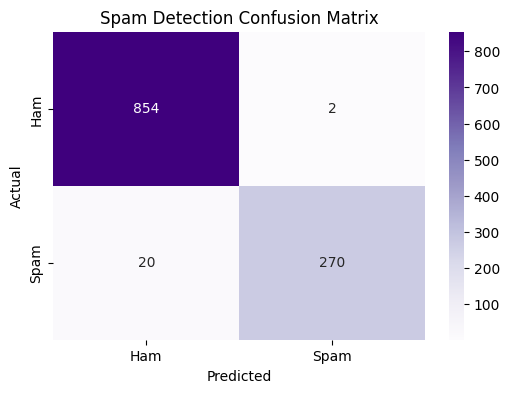


Testing sample message: 'Subject: Urgent! Your account has been compromised. Click here to reset your password immediately.'
Result: SPAM


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. LOAD DATA
# Using your uploaded 'emails.csv'
df = pd.read_csv('emails.csv')

# --- DATA CLEANING ---
# Your CSV has many trailing commas/empty columns. Let's keep only the two we need.
df = df[['text', 'spam']]

# Handling Missing Values: Remove any row where text or the spam label is missing
df = df.dropna()

# Ensure 'spam' is treated as an integer (just in case there are strings)
df['spam'] = pd.to_numeric(df['spam'], errors='coerce')
df = df.dropna(subset=['spam'])
df['spam'] = df['spam'].astype(int)

# --- CONFIGURATION ---
TEXT_COL = 'text' 
LABEL_COL = 'spam' 
# ---------------------

print(f"Dataset loaded: {df.shape[0]} messages.")
print("Class Distribution:")
print(df[LABEL_COL].value_counts())

# 2. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    df[TEXT_COL], 
    df[LABEL_COL], 
    test_size=0.2, 
    random_state=42
)

# 3. FEATURE EXTRACTION (TF-IDF)
# Converting text to numbers. We remove 'english' stop words.
tfidf = TfidfVectorizer(stop_words='english', lowercase=True, max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 4. MODEL IMPLEMENTATION (Naive Bayes)
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 5. EVALUATION
y_pred = model.predict(X_test_tfidf)

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\n--- Classification Report ---")
# Mapping 0/1 back to Ham/Spam for the report display
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# 6. VISUALIZATION (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Spam Detection Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 7. TESTING ON NEW MESSAGES
def predict_spam(message):
    message_tfidf = tfidf.transform([message])
    prediction = model.predict(message_tfidf)
    return "SPAM" if prediction[0] == 1 else "HAM"

# Example usage:
sample_msg = "Subject: Urgent! Your account has been compromised. Click here to reset your password immediately."
print(f"\nTesting sample message: '{sample_msg}'")
print(f"Result: {predict_spam(sample_msg)}")